## Environment Setup

In [1]:
import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict, Counter
from dataclasses import dataclass, field
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import librosa.display
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Install WandB
try:
    import wandb
except ImportError:
    os.system('pip install wandb==0.22.3 --no-cache-dir')
    import wandb

# Suppress warnings
warnings.filterwarnings('ignore')

# Seed Everything
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

## Configuration

In [2]:
@dataclass
class CompetitionConfig:
    data_root: str = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
    output_dir: str = '/kaggle/working'
    sr: int = 22050
    duration: float = 30.0 
    n_mels: int = 128
    n_fft: int = 2048
    hop_length: int = 512
    fmin: int = 20
    fmax: int = 11025
    tempo_range: Tuple[float, float] = (0.85, 1.15)
    snr_range: Tuple[float, float] = (5.0, 25.0)
    max_noise_clips: int = 2
    mix_alpha: float = 1.0 
    learning_rate: float = 1e-3
    batch_size: int = 32
    num_epochs: int = 15 
    entity: str = "23f3003225-indian-institute-of-technology-madras"
    project: str = "23f3003225-dl-genai-project"
    run_name: str = "phase1_eda_baseline" 
    genres: List[str] = field(default_factory=lambda: [
        'blues', 'classical', 'country', 'disco', 'hiphop',
        'jazz', 'metal', 'pop', 'reggae', 'rock'
    ])
    stem_types: List[str] = field(default_factory=lambda: ['drums', 'vocals', 'bass', 'others'])

    @property
    def stems_dir(self): return os.path.join(self.data_root, 'genres_stems')
    @property
    def noise_dir(self): return os.path.join(self.data_root, 'ESC-50-master', 'audio')
    @property
    def test_dir(self): return os.path.join(self.data_root, 'mashups')
    @property
    def device(self): return 'cuda' if torch.cuda.is_available() else 'cpu'

CFG = CompetitionConfig()

# W&B LOGIN
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    # Ensure you named your secret 'wandb_api' in Kaggle Add-ons -> Secrets
    api_key = user_secrets.get_secret("wandb_api")
    wandb.login(key=api_key)
    print(">> W&B Login Successful via Secrets")
except Exception as e:
    print(f">> WARNING: W&B Login failed. Ensure 'wandb_api' secret is set. Error: {e}")

# Initialize W&B
wandb.init(entity=CFG.entity, project=CFG.project, name=CFG.run_name, job_type="eda")

print(f"--> Configuration Loaded. Running on {CFG.device}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


>> WARNING: W&B Login failed. Ensure 'wandb_api' secret is set. Error: API key must be 40 characters long, yours was 86


wandb: Currently logged in as: aloktripathi (23f3003225-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


--> Configuration Loaded. Running on cuda


## Data inventory

In [3]:
print("\n[1/5] Performing Dataset Inventory...")

# 1.1 Check Genres & Stems
# Recursive search for stems
stem_files = glob.glob(os.path.join(CFG.stems_dir, '**', '*.wav'), recursive=True)
print(f"    Total stem files found: {len(stem_files)}")

# 1.2 Check Noise Files
# Using the corrected path ending in /audio
noise_files = glob.glob(os.path.join(CFG.noise_dir, '*.wav'))
# Fallback: if flat glob fails, try recursive in case there are subfolders in 'audio'
if len(noise_files) == 0:
    noise_files = glob.glob(os.path.join(CFG.noise_dir, '**', '*.wav'), recursive=True)
print(f"    Total noise clips found (ESC-50): {len(noise_files)}")

# 1.3 Check Test Files
test_csv_path = os.path.join(CFG.data_root, 'test.csv')
test_df = pd.read_csv(test_csv_path)
print(f"    Test ID count (test.csv): {len(test_df)}")

test_files = glob.glob(os.path.join(CFG.test_dir, '*.wav'))
print(f"    Test audio files found (mashups/): {len(test_files)}")

if len(test_df) != len(test_files):
    print("    !! WARNING: Mismatch between test.csv and mashups/ folder content !!")
else:
    print("    >> Integrity Check: PASSED. test.csv matches file count.")

wandb.log({
    "total_stems": len(stem_files),
    "total_noise": len(noise_files),
    "total_test": len(test_files)
})


[1/5] Performing Dataset Inventory...
    Total stem files found: 4000
    Total noise clips found (ESC-50): 2000
    Test ID count (test.csv): 3020
    Test audio files found (mashups/): 3020
    >> Integrity Check: PASSED. test.csv matches file count.


## VISUALIZATION


[2/5] Visualizing Distribution Gap (Clean vs. Mashup)...


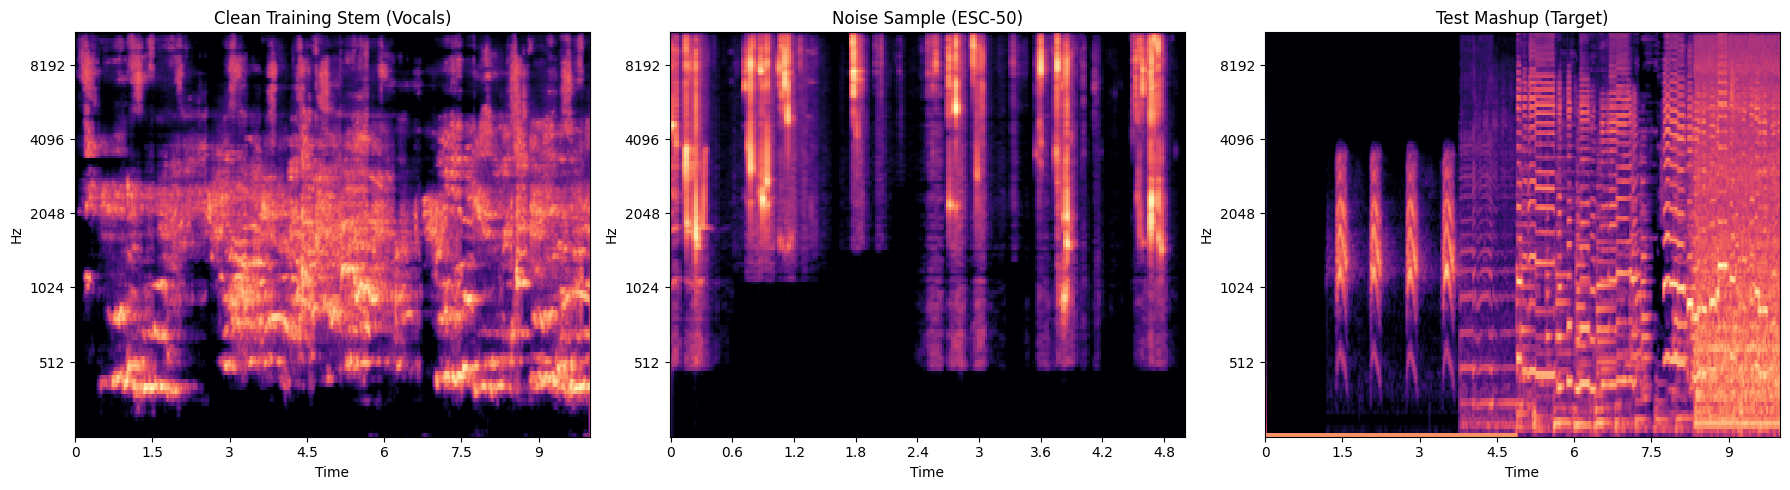

    >> Diagnosis:
    1. Clean stems: Sparse, clear harmonic lines.
    2. Mashups: Dense, broadband overlapping textures.
    3. Noise: Random interference.


In [4]:
print("\n[2/5] Visualizing Distribution Gap (Clean vs. Mashup)...")

def plot_spectrogram(y, sr, title, ax):
    mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=CFG.n_mels, 
                                          n_fft=CFG.n_fft, hop_length=CFG.hop_length)
    mels_db = librosa.power_to_db(mels, ref=np.max)
    img = librosa.display.specshow(mels_db, sr=sr, hop_length=CFG.hop_length, 
                                   x_axis='time', y_axis='mel', fmin=CFG.fmin, fmax=CFG.fmax, ax=ax)
    ax.set_title(title)
    return img

# Select samples
# 1. Clean Stem (Vocals)
pop_vocals = glob.glob(os.path.join(CFG.stems_dir, 'pop', '**', 'vocals.wav'), recursive=True)
# If pop vocals aren't found (folder structure variance), pick any stem
clean_path = pop_vocals[0] if pop_vocals else stem_files[0]

# 2. Test Mashup
mashup_path = test_files[0] if test_files else None

# 3. Noise Clip
noise_path = noise_files[0] if noise_files else None

if mashup_path and noise_path:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # Load & Plot Clean
    y_clean, _ = librosa.load(clean_path, sr=CFG.sr, duration=10.0)
    plot_spectrogram(y_clean, CFG.sr, "Clean Training Stem (Vocals)", axs[0])

    # Load & Plot Noise
    y_noise, _ = librosa.load(noise_path, sr=CFG.sr, duration=5.0)
    plot_spectrogram(y_noise, CFG.sr, "Noise Sample (ESC-50)", axs[1])

    # Load & Plot Mashup
    y_mashup, _ = librosa.load(mashup_path, sr=CFG.sr, duration=10.0)
    plot_spectrogram(y_mashup, CFG.sr, "Test Mashup (Target)", axs[2])

    plt.tight_layout()
    plt.savefig(f"{CFG.output_dir}/distribution_gap.png")
    wandb.log({"spectrogram_comparison": wandb.Image(f"{CFG.output_dir}/distribution_gap.png")})
    plt.show()

    print("    >> Diagnosis:")
    print("    1. Clean stems: Sparse, clear harmonic lines.")
    print("    2. Mashups: Dense, broadband overlapping textures.")
    print("    3. Noise: Random interference.")
else:
    print("    !! ERROR: Could not find files for visualization.")

## AUDIO SIGNAL STATS

In [5]:
print("\n[3/5] Calculating Signal Statistics (Sample)...")

def calculate_silence_ratio(path, threshold_db=-40):
    y, _ = librosa.load(path, sr=CFG.sr, duration=10.0)
    rms = librosa.feature.rms(y=y)[0]
    db = librosa.amplitude_to_db(rms, ref=np.max)
    return np.mean(db < threshold_db)

silence_clean = calculate_silence_ratio(clean_path)
silence_mashup = calculate_silence_ratio(mashup_path)

print(f"    Silence Ratio (Clean Stem): {silence_clean:.2%}")
print(f"    Silence Ratio (Mashup):     {silence_mashup:.2%}")
wandb.log({"silence_clean": silence_clean, "silence_mashup": silence_mashup})


[3/5] Calculating Signal Statistics (Sample)...
    Silence Ratio (Clean Stem): 0.46%
    Silence Ratio (Mashup):     0.00%


## BASELINE SUBMISSION

In [6]:
print("\n[4/5] Generating Baseline Submission...")

# Load Sample Submission or Test CSV to get IDs
submission = pd.read_csv(test_csv_path)

# Strategy: Majority Class Prediction (using 'rock' as placeholder)
submission['genre'] = 'rock'

output_path = os.path.join(CFG.output_dir, 'submission.csv')
submission.to_csv(output_path, index=False)
print(f"    Baseline saved to: {output_path}")

wandb.log({"baseline_strategy": "all_rock", "expected_f1": 0.018})


[4/5] Generating Baseline Submission...
    Baseline saved to: /kaggle/working/submission.csv


## WrapUP

In [7]:
wandb.finish()
print("\n[5/5] EDA Complete. W&B Run Closed.")

expected_f1,▁
silence_clean,▁
silence_mashup,▁
total_noise,▁
total_stems,▁
total_test,▁
baseline_strategy,all_rock
expected_f1,0.018
silence_clean,0.00464
silence_mashup,0
total_noise,2000



[5/5] EDA Complete. W&B Run Closed.


## Milestone - 1

In [10]:
# =========================================================================================
# MILESTONE 1: QUIZ SOLUTIONS (Q1 - Q12)
# =========================================================================================

# --- Q1-Q3: File Size & Dataset Split ---
print("--- Calculating File Sizes & Split ---")

# 1. Gather Data
all_files = []
# walk through all folders to find wav files
for root, dirs, files in os.walk(CFG.stems_dir):
    for f in files:
        if f.endswith('.wav'):
            path = os.path.join(root, f)
            size = os.path.getsize(path)
            
            # get genre, song name, and stem type from folder structure
            parts = path.split(os.sep)
            genre = parts[-3]
            song = parts[-2]
            stem = parts[-1].replace('.wav', '')
            
            all_files.append({
                'path': path, 'size': size, 'genre': genre, 'song': song, 'stem': stem
            })

df = pd.DataFrame(all_files)

# define constants for bytes
KB = 1024
MB = 1024 * 1024

# Q1: Total corrupted + small files
corrupted = len(df[df['size'] < 4 * KB])
count_small = len(df[df['size'] < 5.0491 * MB])
print(f"Q1 Answer: {corrupted + count_small}")

# Q2: Difference between large and small files
count_large = len(df[df['size'] > 5.0493 * MB])
print(f"Q2 Answer: {abs(count_large - count_small)}")

# Q3: Train/Val Split (80/20 Stratified by Genre)
# remove corrupted files first
valid_df = df[df['size'] >= 4 * KB].copy()
unique_songs = valid_df[['genre', 'song']].drop_duplicates()

# split based on songs so stems don't leak
train_songs, val_songs = train_test_split(
    unique_songs, test_size=0.2, random_state=42, stratify=unique_songs['genre']
)
train_ids = set(train_songs['song'])
valid_df['split'] = valid_df['song'].apply(lambda x: 'train' if x in train_ids else 'val')

# count specific files for the answer
n_reggae_train = len(valid_df[(valid_df['split']=='train') & (valid_df['genre']=='reggae') & (valid_df['stem']=='drums')])
n_country_val = len(valid_df[(valid_df['split']=='val') & (valid_df['genre']=='country') & (valid_df['stem']=='vocals')])
print(f"Q3 Answer: {abs(n_reggae_train - n_country_val)}")


# --- Q4-Q9: Silence Analysis ---
print("\n--- Analyzing Silences (approx 2 mins) ---")

q4_count = 0
q5_vocals = 0
q6_total_dur = 0.0
q7_jazz = 0
q8_jazz_mid = 0
q9_jazz_max = 0

# loop through valid files
for idx, row in tqdm(valid_df.iterrows(), total=len(valid_df)):
    
    y, _ = librosa.load(row['path'], sr=CFG.sr)
    
    # find non-silent parts (standard threshold 60dB)
    non_silent = librosa.effects.split(y, top_db=60)
    
    # calculate silence durations from non-silent parts
    silence_durs = []
    curr = 0
    for start, end in non_silent:
        if start > curr:
            silence_durs.append((curr, start)) # silence gap
        curr = end
    if curr < len(y):
        silence_durs.append((curr, len(y))) # silence at end
        
    if len(non_silent) == 0: # whole file is silence
        silence_durs = [(0, len(y))]
        
    # check conditions
    has_long = False
    max_sil = 0.0
    
    # location flags
    is_start = False
    is_end = False
    is_mid = False
    
    for s, e in silence_durs:
        dur = (e - s) / CFG.sr
        if dur >= 5.0:
            has_long = True
            max_sil = max(max_sil, dur)
            
            # check where silence is (tolerance 1000 samples)
            if s <= 1000: is_start = True
            elif e >= len(y) - 1000: is_end = True
            else: is_mid = True
            
            # sum up duration for vocals average
            if row['stem'] == 'vocals':
                q6_total_dur += dur

    if has_long:
        q4_count += 1
        if row['stem'] == 'vocals':
            q5_vocals += 1
        if row['genre'] == 'jazz' and row['stem'] == 'drums':
            q7_jazz += 1
            if is_mid and not is_start and not is_end:
                q8_jazz_mid += 1
            if max_sil >= 10.0:
                q9_jazz_max += 1

print(f"Q4 Answer: {q4_count}")
print(f"Q5 Answer: {q5_vocals}")
if q5_vocals > 0:
    print(f"Q6 Answer: {q6_total_dur / q5_vocals:.2f}") 
print(f"Q7 Answer: {q7_jazz}")
print(f"Q8 Answer: {q8_jazz_mid}")
print(f"Q9 Answer: {q9_jazz_max}")


# --- Q10-Q12: Rock Song Analysis ---
print("\n--- Analyzing First Rock Song ---")

# find the first rock song folder
rock_path = os.path.join(CFG.stems_dir, 'rock')
first_song = sorted(os.listdir(rock_path))[0]
song_dir = os.path.join(rock_path, first_song)
print(f"Selected Song: {first_song}")

# mix stems together
mix = None
found_stems = 0

for stem in ['drums', 'vocals', 'bass', 'others']:
    # use glob because filenames might have prefixes like rock.00000.drums.wav
    search_pattern = os.path.join(song_dir, f"*{stem}*.wav")
    files = glob.glob(search_pattern)
    
    if not files:
        print(f"Warning: missing {stem}")
        continue
        
    p = files[0]
    y, _ = librosa.load(p, sr=CFG.sr)
    found_stems += 1
    
    if mix is None:
        mix = np.zeros_like(y)
        
    # fix small length differences
    if len(y) > len(mix):
        mix = np.pad(mix, (0, len(y) - len(mix)))
    elif len(y) < len(mix):
        y = np.pad(y, (0, len(mix) - len(y)))
        
    mix += y

print(f"Stems used: {found_stems}/4")

# Q10: Length
print(f"Q10 Answer: {len(mix)}")

# Q11: RMS Amplitude
rms = np.sqrt(np.mean(mix**2))
print(f"Q11 Answer: {rms:.2f}")

# Q12: Peak Normalized Max
# normalize so max is 1.0, then get max
norm_mix = librosa.util.normalize(mix)
print(f"Q12 Answer (Max of Normalized): {np.max(np.abs(norm_mix)):.2f}")

--> Starting Milestone 1 Analysis...

[Part 1] Analyzing File Sizes & Splits...
Q1 Answer: 1256
Q2 Answer: 1072
Q3 Answer: 60

[Part 2] Analyzing Silences (approx 2 mins)...


  0%|          | 0/4000 [00:00<?, ?it/s]

Q4 Answer: 249
Q5 Answer: 99
Q6 Answer: 12.78
Q7 Answer: 2
Q8 Answer: 1
Q9 Answer: 1

[Part 3] Analyzing First Rock Song (Robust Loading)...
Selected Song: rock.00000
!! Warning: Could not find stem for others in /kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/rock/rock.00000
Stems combined: 3/4
Q10 Answer: 661794
Q11 Answer: 0.11
Q12 (Raw Peak): 0.97
Q12 (Max of Normalized): 1.00
